In [198]:
from model_name import name_denoise_model, name_superres_model, name_estimator_model
import os
from enchaned_denoiser import *
from upscaler import *
from estimator import NoiseEstimator
import torch
from datasets import CascadeBlindDataset
import torch.utils.data as data
from metrics import SSIM
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt 
from torchsummary import summary

In [199]:
np.random.seed(13)
torch.manual_seed(13)
torch.cuda.manual_seed(13)

In [200]:
DATASET_PATH = 'sidds'
DENOISE_MODELS_PATH = 'denoise_models'
UPSCALE_MODELS_PATH = 'upscale_models'
ESTIMATOR_MODELS_PATH = 'estimator_models'

In [201]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [202]:
denoise_parameters = {
    'architecture': 'ED', # EnhancedDenoiser
    'noise_map': True, # True, False
    'loss': 'MSE', # MSE, L1
    'learning_rate': 0.0001,
    'patch_size': 128,
    'scale_factor': 2,
    'noise_level': None, # 15, 25, 50, None
    'num_blocks': 8,
    'attention': None, # CBAM, Channel, Spatial, None
    'reduction': 8,
    'dilation': 1,  # 1, 2
    'res_scale': 1, # 0.1, 1
    'early_stopping': True # True, False
}

In [203]:
denoise_model_name = name_denoise_model(*denoise_parameters.values())

In [204]:
denoise_model_name = 'ED_nm_MSE_lr1e-04_ps128_sf2_n15_nb8_CBAM(r8)_es'

In [205]:
superres_parameters = {
    'architecture': 'SR', # SuperResolution
    'loss': 'L1', # MSE, L1
    'learning_rate': 0.0001,
    'patch_size': 128,
    'scale_factor': 2,
    'num_blocks': 8,
    'early_stopping': True # True, False
}

In [206]:
superres_model_name = name_superres_model(*superres_parameters.values())

In [207]:
superres_model_name

'SR_L1_lr1e-04_ps128_sf2_nb8_es'

In [208]:
estimator_parameters = {
    'patch_size': 128,
    'scale_factor': 2,
}

In [209]:
estimator_model_name = name_estimator_model(*estimator_parameters.values())

In [210]:
estimator_model_name

'estimator_ps128_sf2'

In [211]:
if denoise_model_name not in os.listdir(DENOISE_MODELS_PATH) and superres_model_name not in os.listdir(UPSCALE_MODELS_PATH) and estimator_model_name not in os.listdir(ESTIMATOR_MODELS_PATH):
	raise FileNotFoundError

In [212]:
if denoise_parameters['noise_map'] == True:
    channels = 4
else:
    channels = 3

In [213]:
denoiser = torch.load(f'{DENOISE_MODELS_PATH}/{denoise_model_name}/model.pth', weights_only=False)

In [214]:
upscaler = torch.load(f'{UPSCALE_MODELS_PATH}/{superres_model_name}/model.pth', weights_only=False)

In [215]:
estimator = torch.load(f'{ESTIMATOR_MODELS_PATH}/{estimator_model_name}/model.pth', weights_only=False)

In [216]:
denoise_parameters['patch_size']

128

In [217]:
dataset = CascadeBlindDataset(DATASET_PATH, 256, denoise_parameters['scale_factor'])

In [218]:
dataset_loader = data.DataLoader(dataset, batch_size=1, shuffle=False)

In [219]:
criterion = nn.MSELoss()

In [220]:
ssim = SSIM()

In [224]:
summary(estimator)

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv2d: 2-1                       896
|    └─ReLU: 2-2                         --
|    └─Conv2d: 2-3                       9,248
|    └─ReLU: 2-4                         --
|    └─Conv2d: 2-5                       289
|    └─Softplus: 2-6                     --
Total params: 10,433
Trainable params: 10,433
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv2d: 2-1                       896
|    └─ReLU: 2-2                         --
|    └─Conv2d: 2-3                       9,248
|    └─ReLU: 2-4                         --
|    └─Conv2d: 2-5                       289
|    └─Softplus: 2-6                     --
Total params: 10,433
Trainable params: 10,433
Non-trainable params: 0

In [ ]:
# test_epoch_loss = 0
# test_epoch_psnr = 0
# test_epoch_ssim = 0

# denoiser.eval()
# upscaler.eval()
# with torch.no_grad():
#     for pair in dataset_loader:
#         noisy_lr, clean_hr = pair[0].to(device), pair[1].to(device)
#         if denoise_parameters['noise_map'] == True:
#             to_tensor = transforms.ToTensor()
#             if denoise_parameters['noise_level'] is None:
#                 estimator.eval()
#                 noise_map = estimator(noisy_lr).to(device)
#             else:
#                 noise_map = np.full((noisy_lr.shape[2], noisy_lr.shape[3]), denoise_parameters['noise_level'] / 255, dtype=np.float32)
#                 noise_map = to_tensor(noise_map).unsqueeze(0).to(device)
#             noisy_lr = torch.cat([noisy_lr, noise_map], dim=1)
		
#         clean_lr = denoiser(noisy_lr)
#         output = upscaler(clean_lr)
#         loss = criterion(output, clean_hr)
#         mse = torch.mean((output - clean_hr)**2, dim=[1, 2, 3])
        
#         test_epoch_loss += loss.item()
#         test_epoch_psnr += 10 * torch.log10(1/(mse+1e-10)).mean().item()
        
#         test_epoch_ssim += ssim(output, clean_hr).item()

# print(f'Loss on the {len(dataset_loader)} test images: {test_epoch_loss/len(dataset_loader)}')
# print(f'PSNR on the {len(dataset_loader)} test images: {test_epoch_psnr/len(dataset_loader)}')
# print(f'SSIM on the {len(dataset_loader)} test images: {test_epoch_ssim/len(dataset_loader)}')



In [ ]:
# noisy_lr.shape

In [ ]:
# clean_hr.shape

In [ ]:
# output.shape

In [ ]:
noisy, clean = next(iter(dataset_loader))

In [ ]:
with torch.no_grad():
    noisy_cuda = noisy.to(device)
    if denoise_parameters['noise_map'] == True:
        to_tensor = transforms.ToTensor()
        if denoise_parameters['noise_level'] is None:
            noise_map = estimator(noisy_cuda).to(device)
        else:
            noise_map = np.full((noisy_cuda.shape[2], noisy_cuda.shape[3]), denoise_parameters['noise_level'] / 255, dtype=np.float32)
            noise_map = to_tensor(noise_map).unsqueeze(0).to(device)
        
        noisy_cuda = torch.cat([noisy_cuda, noise_map], dim=1)
    
    clean_lr = denoiser(noisy_cuda)
    output = upscaler(clean_lr)
    

In [ ]:
# noise_map = estimator(noisy_cuda).to(device)
noise_map.mean()*255

tensor(8.3128, device='cuda:0')

In [ ]:
mse = torch.mean((output.cpu().data[0] - clean[0])**2)
        
test_psnr = 10 * torch.log10(1/(mse+1e-10)).mean().item()
clean = clean.to(device)
test_ssim = ssim(output, clean).item()

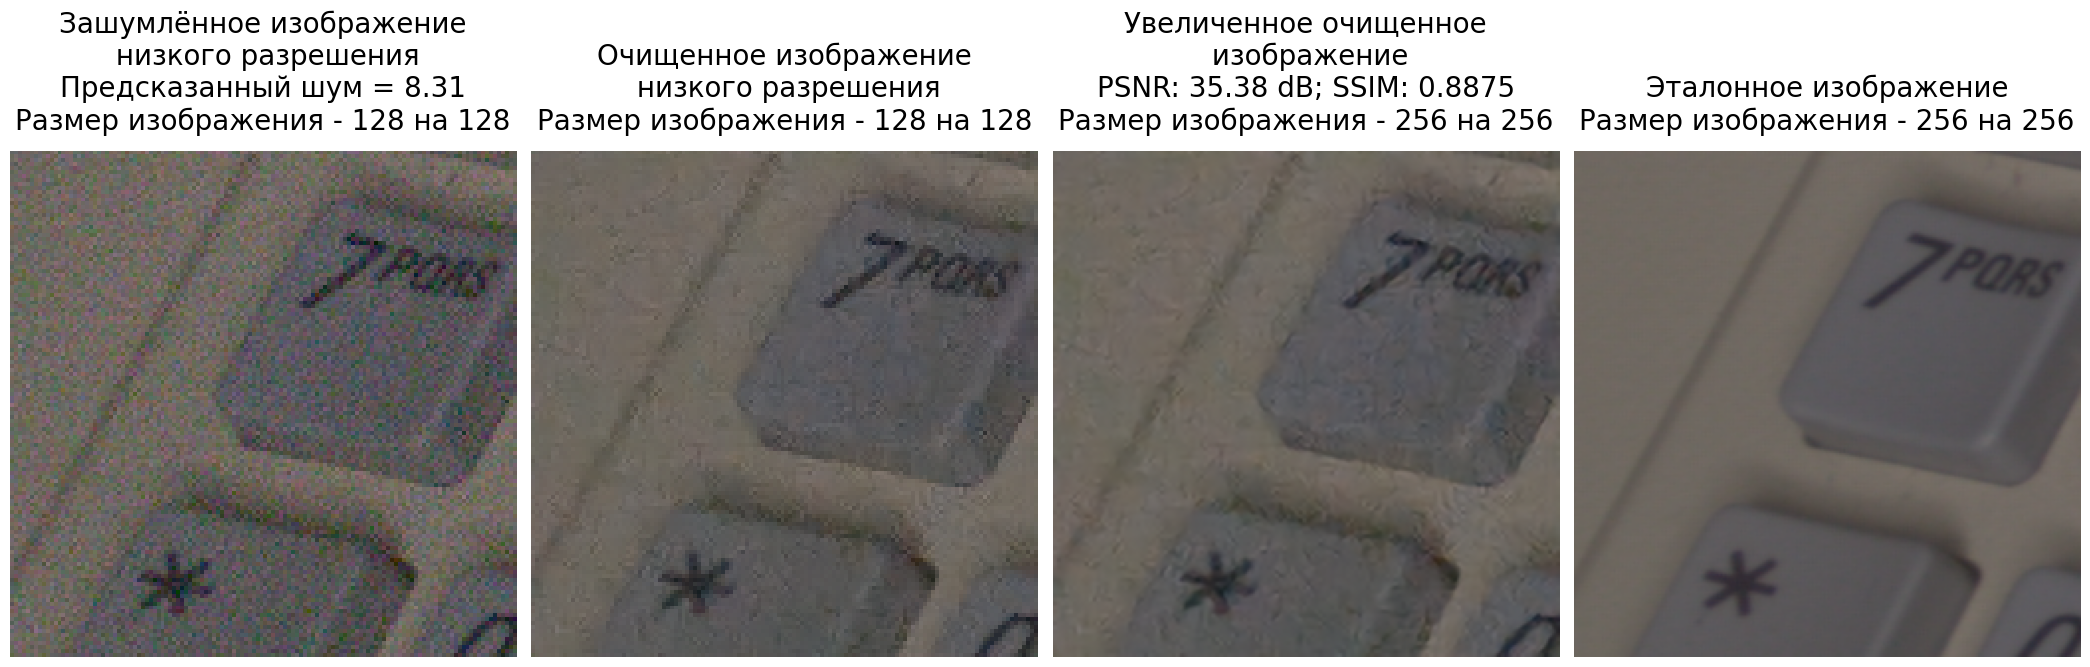

In [ ]:
noise_level = 15  

fig, axes = plt.subplots(1, 4, figsize=(21, 16))

axes[0].imshow(np.transpose(noisy[0][:3, :, :], (1, 2, 0)))
axes[0].set_title(
    f"Зашумлённое изображение\n низкого разрешения\nПредсказанный шум = {noise_map.mean()*255:.2f}\nРазмер изображения - {noisy[0][:3, :, :].shape[1]} на {noisy[0][:3, :, :].shape[1]}",
    fontsize=20, pad=15
)
axes[0].axis('off')

axes[1].imshow(np.transpose(clean_lr.cpu().data.numpy()[0], (1, 2, 0)))
axes[1].set_title(f"Очищенное изображение\n низкого разрешения\nРазмер изображения - {clean_lr[0][:3, :, :].shape[1]} на {clean_lr[0][:3, :, :].shape[1]}",
    fontsize=20, pad=15
)
axes[1].axis('off')

axes[2].imshow(np.transpose(output.cpu().data.numpy()[0], (1, 2, 0)))
axes[2].set_title(f"Увеличенное очищенное\n изображение\nPSNR: {test_psnr:.2f} dB; SSIM: {test_ssim:.4f}\nРазмер изображения - {output[0][:3, :, :].shape[1]} на {output[0][:3, :, :].shape[1]}",
    fontsize=20, pad=15
)
axes[2].axis('off')


axes[3].imshow(np.transpose(clean[0].cpu(), (1, 2, 0)))
axes[3].set_title(f"Эталонное изображение\nРазмер изображения - {clean[0][:3, :, :].shape[1]} на {clean[0][:3, :, :].shape[1]}",
    fontsize=20, pad=15
)
axes[3].axis('off')

plt.tight_layout()
plt.show()
